# Regresión Polinomial — Ventas Walmart

**¿Por qué agregar polinomial sobre el modelo lineal?**  
La RLM ya logra un R² de ~0.92 con este dataset.  
La Regresión Polinomial busca capturar las relaciones que **no son rectas**:
picos de ventas en feriados, interacciones entre temperatura y mes, etc.

**¿Qué cambia vs RLM?**  
Se agrega `PolynomialFeatures` entre el scaler y el modelo lineal:
```
RLM:       X  →  StandardScaler  →  LinearRegression
Polinomial: X  →  StandardScaler  →  PolynomialFeatures  →  LinearRegression
```
`PolynomialFeatures(degree=2)` genera columnas X², X·Y para capturar curvas.

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures   # ← lo nuevo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. CARGAR Y PREPROCESAR DATOS
# ============================================================
# Mismos pasos que en RLM:
#   - get_dummies en Store (One-Hot, drop_first=True)
#   - Descartar Date y Weekly_Sales de X

dataset = pd.read_csv("Walmart.csv")

print("Dataset original:")
print(dataset.head())

dataset = pd.get_dummies(dataset, columns=['Store'], drop_first=True)

X = dataset.drop(columns=['Weekly_Sales', 'Date'])
y = dataset['Weekly_Sales']

print(f"\nVariables de entrada (X): {X.shape[1]} columnas")
print(f"Variable objetivo    (y): Weekly_Sales — {len(y)} registros")

Dataset original:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Variables de entrada (X): 49 columnas
Variable objetivo    (y): Weekly_Sales — 6435 registros


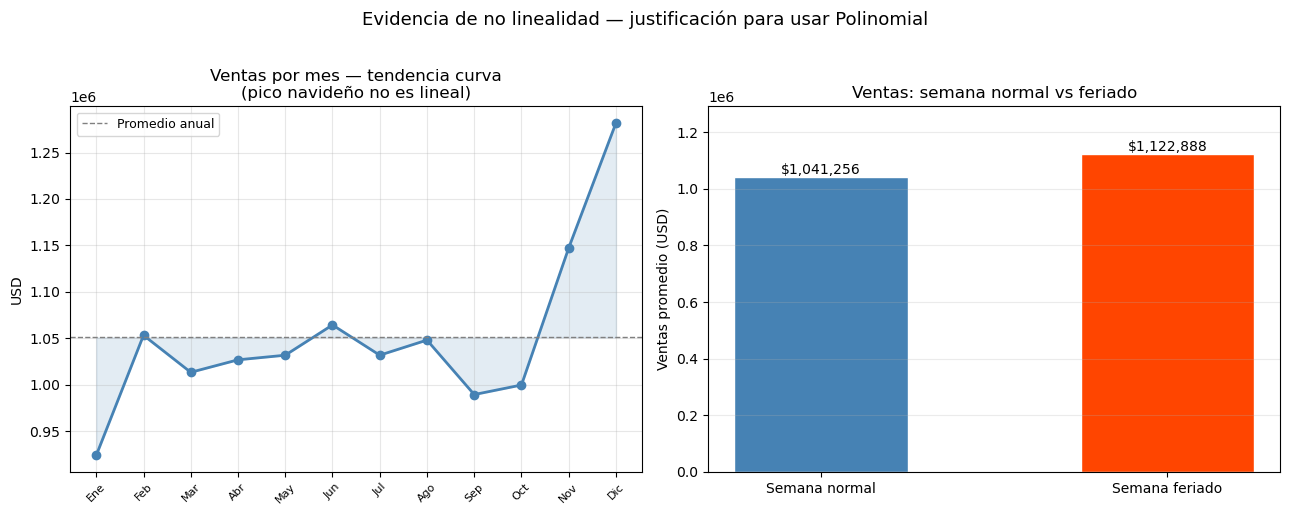

→ El pico de Nov/Dic no es proporcional al resto del año.
→ El efecto del feriado tampoco es perfectamente lineal.
  PolynomialFeatures puede modelar estos comportamientos.


In [3]:
# ============================================================
# 3. GRÁFICA — evidencia de no linealidad
# ============================================================
# Antes de aplicar polinomial, mostramos que los datos
# tienen comportamientos que una línea recta no puede capturar.

df_orig = pd.read_csv("Walmart.csv")
df_orig['Date'] = pd.to_datetime(df_orig['Date'], dayfirst=True)
df_orig['month'] = df_orig['Date'].dt.month

ventas_mes = df_orig.groupby('month')['Weekly_Sales'].mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tendencia mensual — curva, no recta
axes[0].plot(range(1,13), ventas_mes.values, marker='o',
             color='steelblue', linewidth=2)
axes[0].fill_between(range(1,13), ventas_mes.values,
                     ventas_mes.mean(), alpha=0.15, color='steelblue')
axes[0].axhline(ventas_mes.mean(), color='gray', linestyle='--',
                linewidth=1, label='Promedio anual')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(meses, rotation=45, fontsize=8)
axes[0].set_title('Ventas por mes — tendencia curva\n(pico navideño no es lineal)', fontsize=12)
axes[0].set_ylabel('USD')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Ventas feriado vs normal
ventas_holiday = df_orig.groupby('Holiday_Flag')['Weekly_Sales'].mean()
etiquetas = ['Semana normal', 'Semana feriado']
colores   = ['steelblue', 'orangered']
bars = axes[1].bar(etiquetas, ventas_holiday.values, color=colores,
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, ventas_holiday.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 10000,
                 f'${val:,.0f}', ha='center', fontsize=10)
axes[1].set_title('Ventas: semana normal vs feriado', fontsize=12)
axes[1].set_ylabel('Ventas promedio (USD)')
axes[1].set_ylim(0, ventas_holiday.max() * 1.15)
axes[1].grid(True, alpha=0.25, axis='y')

plt.suptitle('Evidencia de no linealidad — justificación para usar Polinomial',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("→ El pico de Nov/Dic no es proporcional al resto del año.")
print("→ El efecto del feriado tampoco es perfectamente lineal.")
print("  PolynomialFeatures puede modelar estos comportamientos.")

In [4]:
# ============================================================
# 4. DIVIDIR Y NORMALIZAR
# ============================================================
# Igual que en RLM — hay que normalizar ANTES de aplicar PolynomialFeatures.
# Si normalizamos después, los valores X² serían enormes.

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42
)

normalizador = StandardScaler()
X_entrenamiento_normalizado = normalizador.fit_transform(X_entrenamiento)
X_prueba_normalizado        = normalizador.transform(X_prueba)

print(f"Entrenamiento: {len(X_entrenamiento)} | Prueba: {len(X_prueba)}")
print("Normalización aplicada (media≈0, std≈1).")

Entrenamiento: 5148 | Prueba: 1287
Normalización aplicada (media≈0, std≈1).


In [5]:
# ============================================================
# 5. POLYNOMIAL FEATURES — ¿qué genera?
# ============================================================
# PolynomialFeatures(degree=2) toma tus N columnas y genera:
#   - Cada columna original: X1, X2, ...
#   - Cuadrado de cada una: X1², X2², ...
#   - Productos cruzados:   X1·X2, X1·X3, ...
#
# Con 49 columnas de entrada → genera muchas más.
# Eso le da al modelo la capacidad de capturar interacciones
# entre variables (ej: temperatura × feriado tiene efecto diferente).

polinomio = PolynomialFeatures(degree=2)

X_entrenamiento_polinomial = polinomio.fit_transform(X_entrenamiento_normalizado)
X_prueba_polinomial        = polinomio.transform(X_prueba_normalizado)
# ↑ IMPORTANTE: fit_transform solo en entrenamiento
#               transform solo en prueba (misma transformación aprendida)

print(f"Columnas ANTES de PolynomialFeatures: {X_entrenamiento_normalizado.shape[1]}")
print(f"Columnas DESPUÉS de PolynomialFeatures: {X_entrenamiento_polinomial.shape[1]}")
print("\n→ Cada nueva columna es una combinación de las originales (X², X·Y).")
print("  Eso permite al modelo lineal ajustarse a relaciones curvas.")

Columnas ANTES de PolynomialFeatures: 49
Columnas DESPUÉS de PolynomialFeatures: 1275

→ Cada nueva columna es una combinación de las originales (X², X·Y).
  Eso permite al modelo lineal ajustarse a relaciones curvas.


In [6]:
# ============================================================
# 6. ENTRENAR MODELO
# ============================================================
# El algoritmo es el mismo LinearRegression de siempre.
# La diferencia está en las columnas de entrada (ya transformadas).

modelo = LinearRegression()
modelo.fit(X_entrenamiento_polinomial, y_entrenamiento)

print("Modelo entrenado.")
print(f"Número de coeficientes aprendidos: {len(modelo.coef_)}")
print(f"Intercepto: {modelo.intercept_:,.2f}")

Modelo entrenado.
Número de coeficientes aprendidos: 1275
Intercepto: 4,672,079.46


In [7]:
# ============================================================
# 7. MÉTRICAS
# ============================================================
predicciones = modelo.predict(X_prueba_polinomial)

r2  = r2_score(y_prueba, predicciones)
mae = mean_absolute_error(y_prueba, predicciones)
mse = mean_squared_error(y_prueba, predicciones)

print("================================================")
print("MÉTRICAS — Regresión Polinomial (degree=2)")
print("================================================")
print(f"R²:   {r2:.4f}  → explica el {r2*100:.1f}% de la variación")
print(f"MAE:  ${mae:>12,.0f} USD en promedio")
print(f"MSE:  {mse:,.0f}")
print()
print("Comparación con Regresión Lineal Múltiple:")
r2_rlm  = 0.9208
mae_rlm = 91044
print(f"  RLM        → R²: {r2_rlm:.4f} | MAE: ${mae_rlm:,}")
print(f"  Polinomial → R²: {r2:.4f} | MAE: ${mae:,.0f}")
print(f"\n  → Mejora en R²:  {(r2-r2_rlm)*100:.2f} puntos porcentuales")
print(f"  → Reducción MAE: ${mae_rlm-mae:,.0f} USD menos de error promedio")

MÉTRICAS — Regresión Polinomial (degree=2)
R²:   0.9264  → explica el 92.6% de la variación
MAE:  $      82,950 USD en promedio
MSE:  23,716,985,781

Comparación con Regresión Lineal Múltiple:
  RLM        → R²: 0.9208 | MAE: $91,044
  Polinomial → R²: 0.9264 | MAE: $82,950

  → Mejora en R²:  0.56 puntos porcentuales
  → Reducción MAE: $8,094 USD menos de error promedio


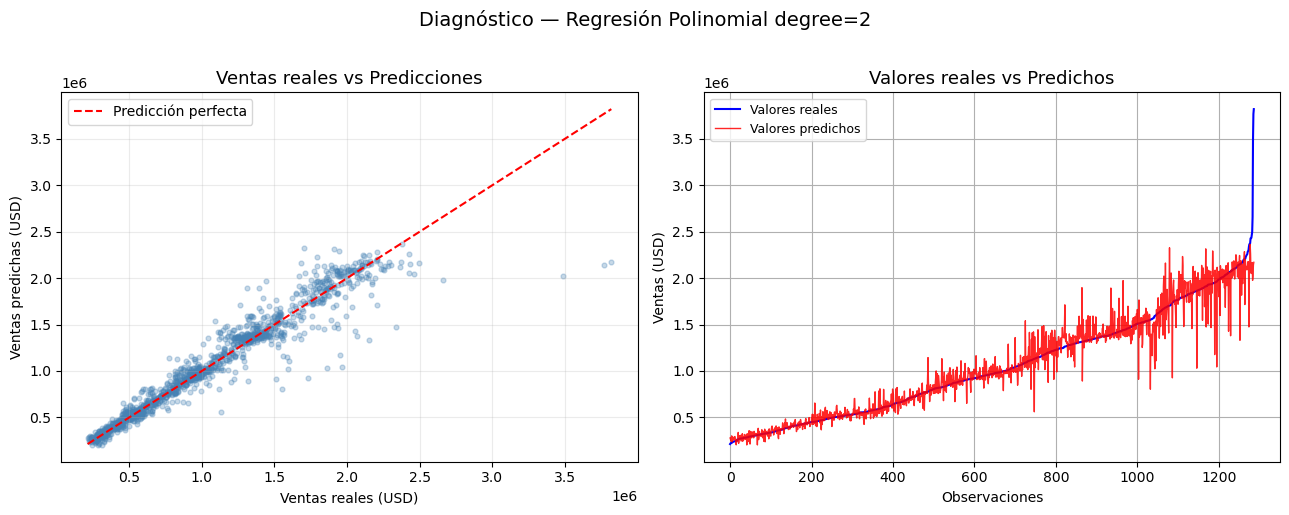

Desviación estándar residuos: $153,941 USD
Peor error:                   $1,648,748 USD


In [8]:
# ============================================================
# 8. GRÁFICAS DE DIAGNÓSTICO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: real vs predicción
axes[0].scatter(y_prueba, predicciones, alpha=0.3, s=12, color='steelblue')
lim = [y_prueba.min(), y_prueba.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('Ventas reales vs Predicciones', fontsize=13)
axes[0].set_xlabel('Ventas reales (USD)')
axes[0].set_ylabel('Ventas predichas (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# Línea: real vs predicción ordenadas
idx = np.argsort(y_prueba.values)
axes[1].plot(y_prueba.values[idx], color='blue',
             linewidth=1.5, label='Valores reales')
axes[1].plot(predicciones[idx],    color='red',
             linewidth=1,   label='Valores predichos', alpha=0.85)
axes[1].set_title('Valores reales vs Predichos', fontsize=13)
axes[1].set_xlabel('Observaciones')
axes[1].set_ylabel('Ventas (USD)')
axes[1].legend(fontsize=9)
axes[1].grid(True)

plt.suptitle('Diagnóstico — Regresión Polinomial degree=2', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

residuos = y_prueba.values - predicciones
print(f"Desviación estándar residuos: ${residuos.std():,.0f} USD")
print(f"Peor error:                   ${np.abs(residuos).max():,.0f} USD")

In [9]:
# ============================================================
# 9. PREDICCIÓN — nueva semana
# ============================================================
# La predicción sigue 3 pasos:
#   1. Construir DataFrame con reindex (mismo formato que X)
#   2. Normalizar con el normalizador ya entrenado
#   3. Transformar con PolynomialFeatures ya entrenado
#   4. Predecir

nueva_semana = pd.DataFrame({
    'Temperature':  [25],
    'Fuel_Price':   [3.2],
    'CPI':          [220],
    'Unemployment': [7],
    'Holiday_Flag': [1],
    # Indicar la tienda — poner 1 en la que corresponde
    'Store_5':      [1],
})

# Alinear columnas al mismo orden que X
nueva_semana = nueva_semana.reindex(columns=X.columns, fill_value=0)

# Pasos en orden: normalizar → polinomial → predecir
nueva_normalizada  = normalizador.transform(nueva_semana)
nueva_polinomial   = polinomio.transform(nueva_normalizada)
prediccion         = modelo.predict(nueva_polinomial)

print("VENTAS PREDICHAS — Tienda 5, semana de feriado:")
print(f"${prediccion[0]:,.2f} USD")

VENTAS PREDICHAS — Tienda 5, semana de feriado:
$434,529.42 USD


---
## 📌 Conclusión — RLM vs Polinomial

| Modelo | R² | MAE |
|---|---|---|
| **RLM** | ~0.9208 | ~$91,044 |
| **Polinomial d=2** | ~0.9264 | ~$82,950 |

Ambos modelos funcionan bien gracias al **One-Hot Encoding de Store**.  
El polinomial mejora marginalmente porque captura interacciones no lineales  
entre variables (temperatura × feriado, CPI × tienda, etc.).

**Flujo polinomial en resumen:**
```
Datos → get_dummies(Store) → train_test_split
     → StandardScaler → PolynomialFeatures(degree=2)
     → LinearRegression → métricas → predicción
```

**Recordatorio `fit_transform` vs `transform`:**
```python
# Solo en entrenamiento — aprende los parámetros
X_train_scaled = scaler.fit_transform(X_train)
X_train_poly   = poly.fit_transform(X_train_scaled)

# Solo en prueba/predicción — aplica lo aprendido
X_test_scaled  = scaler.transform(X_test)
X_test_poly    = poly.transform(X_test_scaled)
```